## Spatial and Temporal Analysis of Urban Issue Reports in Zurich

# Data Preparation and Cleaning #
The raw datasets are loaded and prepared for spatial and temporal analysis. The workflow includes data loading, variable selection, data type conversion, and the transformation of tabular data into geospatial formats. Furthermore, a consistent coordinate reference system (CH1903+ / LV95) is defined and applied to ensure spatial consistency across all datasets.

In [93]:
import pandas as pd
import matplotlib.pyplot as plt
from shapely.geometry import Point
from shapely import wkt
import geopandas as gpd
import mapclassify
import functions 

raw_reports = pd.read_csv("../data/raw/zwn_meldungen.csv")
raw_neighborhoods = pd.read_csv("../data/raw/quartiere_zürich.csv")
raw_population_size = pd.read_csv("../data/raw/populationsize_zh.csv")

# Keep only variables needed for spatial and temporal analysis
reports = raw_reports[["service_name","requested_datetime","e","n","status","updated_datetime"]]
neighborhoods = raw_neighborhoods[["qname","geometry"]]
population_size = raw_population_size[["QuarLang","AnzBestWir","StichtagDatJahr"]]

# Standardize column names to avoid merge conflicts across datasets
new_names_reports = {
    "service_name":"Category",
    "e":"East",
    "n":"North",
    "requested_datetime":"Report_time",
    "updated_datetime":"Resolved_time",
    }
reports = reports.rename(columns=new_names_reports)

new_names_neighborhoods = {
    "qname":"Neighborhoods",
    "geometry": "Geometry",
    }
neighborhoods = neighborhoods.rename(columns=new_names_neighborhoods)

new_names_population_size = {
    "QuarLang":"Neighborhoods",
    "AnzBestWir":"Population_size",
    "StichtagDatJahr":"Year"
    }
population_size = population_size.rename(columns=new_names_population_size)

# Verify data completeness before spatial analysis
reports.isna().sum()
neighborhoods.isna().sum()
population_size.isna().sum()


#-------------------------------------------------------------------------------------------------------------------------
# Prepare reports dataset
#-------------------------------------------------------------------------------------------------------------------------

reports["Report_time"] = pd.to_datetime(reports["Report_time"], format ="%Y-%m-%dT%H:%M:%S")
reports["Resolved_time"] = pd.to_datetime(reports["Resolved_time"], format ="%Y-%m-%dT%H:%M:%S")

# Create GeoDataFrame for spatial join
reports_gdf = gpd.GeoDataFrame(
    reports,
    geometry=gpd.points_from_xy(reports["East"], 
    reports["North"])
)
# Assign coordinate reference system (Swiss LV95 / EPSG:2056) for spatial join
reports_gdf = reports_gdf.set_crs(epsg=2056)


#-------------------------------------------------------------------------------------------------------------------------
# Prepare neighborhoods dataset
#-------------------------------------------------------------------------------------------------------------------------

neighborhoods["Geometry"] = neighborhoods["Geometry"].apply(wkt.loads)

# Create GeoDataFrame for spatial join
neighborhoods_gdf = gpd.GeoDataFrame(
    neighborhoods,
    geometry="Geometry")

# Assign coordinate reference system (Swiss LV95 / EPSG:2056) for spatial join
neighborhoods_gdf = neighborhoods_gdf.set_crs(epsg=2056)


#-------------------------------------------------------------------------------------------------------------------------
# Prepare poulation size dataset
#-------------------------------------------------------------------------------------------------------------------------

population_size_2025= population_size[population_size["Year"]	== 2025]


## Spatial Join ##
A left join is used to retain all reports, even if some do not match a neighborhood polygon.\
Intersects is preferred over within to minimize unmatched observations

In [94]:
reports_gdf_with_neighborhoods_gdf = gpd.sjoin(reports_gdf,neighborhoods_gdf, how="left", predicate ="intersects")

## Question 1: How does the number of reports vary across neighborhoods?
To answer this question, reports are aggregated at the neighborhood level and normalized by population size for better comparison between neighborhoods. The results are visualized using a choropleth map. Class breaks are determined using Natural Breaks classification. The number of class breaks is chosen with the help of a histogram.

C:\Users\arina\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


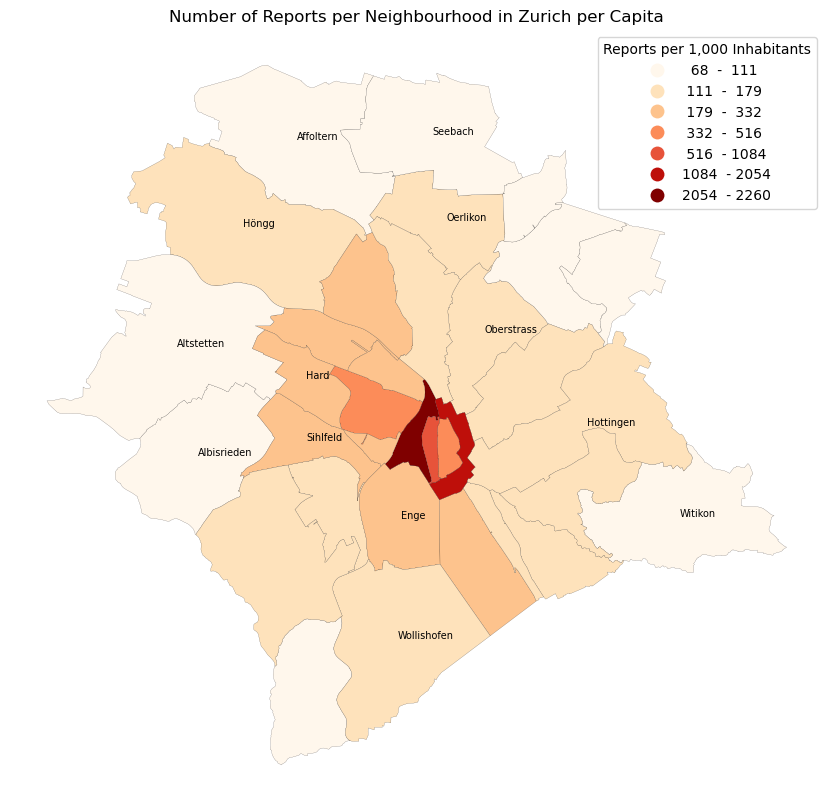

C:\Users\arina\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


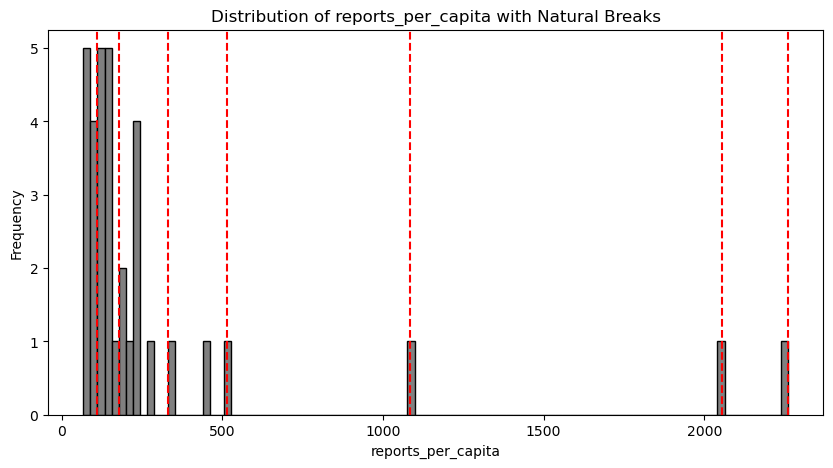

In [98]:
#---------------------------------------------------------------------------------------------------------------------
# Build Analysis Dataset
#---------------------------------------------------------------------------------------------------------------------

# # Aggregate reports per neighborhood to compare reporting intensity across neighborhoods
reports_count = reports_gdf_with_neighborhoods_gdf.groupby(["Neighborhoods"]).size().reset_index(name="count")

reports_count_gdf = neighborhoods_gdf.merge(reports_count, on="Neighborhoods",how="left")
reports_count_pop_gdf = reports_count_gdf.merge(population_size_2025, on="Neighborhoods",how="left")

# Scale values per 1,000 inhabitants for better readability
reports_count_pop_gdf["reports_per_capita"] = (reports_count_pop_gdf["count"]/reports_count_pop_gdf["Population_size"] *1000)

#----------------------------------------------------------------------------------------------
# Create Chlorpleth Map
#----------------------------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(20,10)) 

reports_count_pop_gdf.plot(
    column="reports_per_capita",
    scheme = "naturalbreaks",
    k = 7,
    edgecolor = "black",
    legend=True,
    linewidth = 0.1,
    cmap="OrRd",
    ax=ax, 
    legend_kwds={"title": "Reports per 1,000 Inhabitants","fmt": "{:.0f}"})

ax.set_title("Number of Reports per Neighbourhood in Zurich per Capita")
ax.axis("off")

# improve map readability by enhancing legend formatting and adding neighborhoods labels
functions.clean_legend_labels(ax)
functions.add_labels_zurich(ax,reports_count_pop_gdf,names=["Affoltern","Seebach","Oerlikon","Höngg","Altstetten",
                                                            "Albisrieden","Enge","Wollishofen","Witikon","Hottingen",
                                                            "Sihlfeld","Hard","Oberstrass"])

plt.show()

#----------------------------------------------------------------------------------------------------------------------------------------
# Create Histogram
#----------------------------------------------------------------------------------------------------------------------------------------
functions.histogram_natural_breaks(reports_count_pop_gdf,column="reports_per_capita",k=7)
